# Uma Abordagem Híbrida e Explicável para Análise de Sentimento Contextual em Críticas Musicais


<p align="center">
  <img src="https://www.uema.br/wp-content/uploads/2018/04/pecs.png" alt="" width="30%"">
</p>


<p align="center"> Universidade Estadual do Maranhão</p>
<p align="center"> Programa de Pós-Graduação em Engenharia de Computação e Sistemas</p>
<p align="center"> Ciência dos Dados</p>

***

## Fernando Almeida do Carmo
## 07/01/2026

***

__Contextualização e Problema__
1. Críticas musicais são ricas em metáforas, gírias e subjetividade
2. Polissemia Contextual - A polaridade de um adjetivo varia conforme o gênero
3. Modelos tradicionais (Unimodais/Só Texto) ignoram o contexto estilístico

<div align="center">
  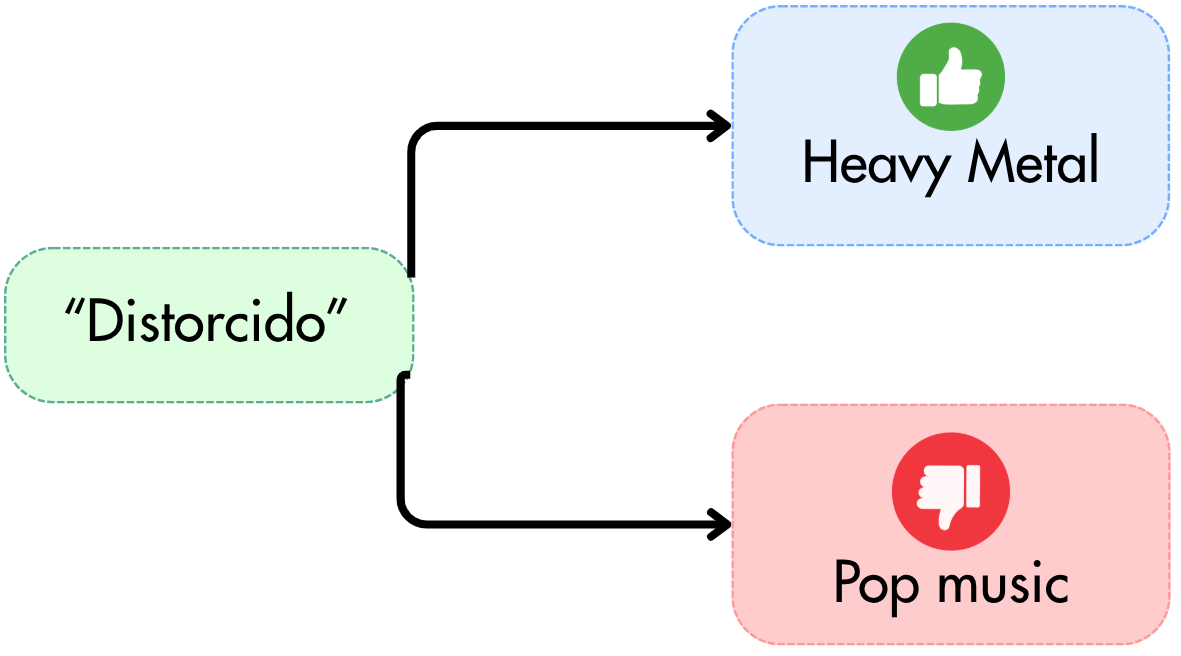
</div>


***


In [ ]:
import sqlite3
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Conexão
#https://pitchfork.com/
#https://www.kaggle.com/datasets/nolanbconaway/pitchfork-data
con = sqlite3.connect('/content/drive/MyDrive/MESTRADO/Disciplinas/Deep Learning/Paper - analysis/database.sqlite')


# 2. Query Corrigida (JOIN Triplo)
# Pegamos:
# - Texto da tabela 'content'
# - Nota da tabela 'reviews'
# - Gênero da tabela 'genres'
sql_query = """
SELECT
    r.reviewid,
    c.content as text,
    r.score,
    g.genre
FROM reviews r
JOIN content c ON r.reviewid = c.reviewid
JOIN genres g ON r.reviewid = g.reviewid
"""

df = pd.read_sql_query(sql_query, con)
con.close()

# 3. Limpeza de Dados
# Remover duplicatas: Um review pode ter 2 gêneros (ex: Rock e Electronic).
# Para este artigo, simplificamos mantendo apenas o primeiro registro.
df = df.drop_duplicates(subset='reviewid', keep='first')

# Remover linhas onde o texto ou o gênero sejam nulos/vazios
df = df.dropna(subset=['text', 'genre', 'score'])
df = df[df['text'] != ""] # Garante que não tem texto vazio

# 4. Criação do Target (Sentiment Label)
# Regra: Nota < 6.5 = Negativo/Neutro (0) | Nota >= 6.5 = Positivo (1)
# O limiar de 6.5 cria um balanço interessante na Pitchfork.
def create_sentiment(score):
    return 1 if score >= 6.5 else 0

df['label'] = df['score'].apply(create_sentiment)

# Verificação Final
print(f"Dataset Carregado com Sucesso!")
print(f"Total de Reviews: {len(df)}")
print("-" * 30)
print(df[['text', 'genre', 'score', 'label']].head())

# Verifique o balanceamento das classes
print("\nDistribuição das Classes (0=Neg, 1=Pos):")
print(df['label'].value_counts(normalize=True))

Dataset Carregado com Sucesso!
Total de Reviews: 16015
------------------------------
                                                text       genre  score  label
0  “Trip-hop” eventually became a ’90s punchline,...  electronic    9.3      1
1  Eight years, five albums, and two EPs in, the ...       metal    7.9      1
2  Minneapolis’ Uranium Club seem to revel in bei...        rock    7.3      1
3  Kleenex began with a crash. It transpired one ...        rock    9.0      1
4  It is impossible to consider a given release b...  electronic    8.1      1

Distribuição das Classes (0=Neg, 1=Pos):
label
1    0.74399
0    0.25601
Name: proportion, dtype: float64


In [ ]:
df.genre.value_counts()

,count
genre,
rock,6425
electronic,3872
experimental,1614
rap,1308
pop/r&b,1047
metal,730
folk/country,646
jazz,220
global,153


<div align="center">
  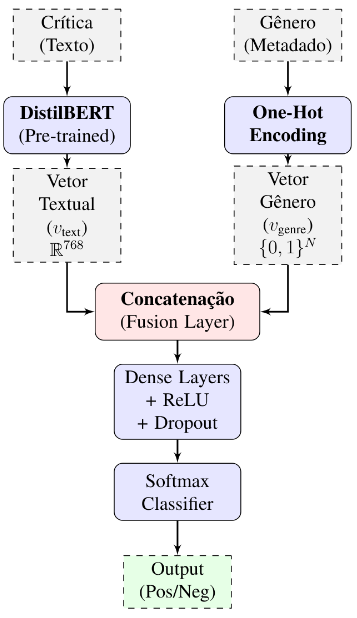
  <p><em>Arquitetura do Modelo Hibrido</em></p>
</div>

In [ ]:
import keras_nlp
import keras
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.utils import class_weight
import numpy as np
from tensorflow.keras import backend as K

# 1. Configurações
BATCH_SIZE = 32
EPOCHS = 3  # Começamos com poucas épocas para testar rápido
PRESET = "distil_bert_base_en_uncased" # Modelo leve e eficiente

# 2. Divisão Estratificada (Mantém a proporção 75/25 nos treinos e testes)
X = df[['text', 'genre']]
y = df['label']

# Split: 80% Treino, 20% Teste (Simplificado para o artigo)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 3. Calcular Pesos das Classes (Para corrigir o desbalanceamento)
# Isso diz ao modelo: "Atenção redobrada na classe 0!"
weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weights = dict(enumerate(weights))
print(f"Pesos calculados: {class_weights}") # Provavelmente a classe 0 terá peso ~1.9 e a 1 terá ~0.6

# 4. Preparação dos Inputs para o Keras
# O KerasNLP precisa dos arrays numpy separados
train_texts = X_train['text'].to_numpy()
train_genres = X_train['genre'].to_numpy()
test_texts = X_test['text'].to_numpy()
test_genres = X_test['genre'].to_numpy()

# Mapeamento dos Gêneros para Números (One-Hot)
unique_genres = df['genre'].unique().tolist()
genre_lookup = keras.layers.StringLookup(
    vocabulary=unique_genres, output_mode="one_hot"
)

# 5. Construção do Modelo Híbrido
# --- Input A: Texto (Transformer) ---
preprocessor = keras_nlp.models.DistilBertPreprocessor.from_preset(
    PRESET, sequence_length=256
)
backbone = keras_nlp.models.DistilBertBackbone.from_preset(PRESET)
# Congelamos o backbone inicialmente para não destruir os pesos pré-treinados
backbone.trainable = False

# Limpa a memória de modelos anteriores criados nesta sessão
K.clear_session()
text_input = keras.Input(shape=(), dtype="string", name="text_input")
x_text = preprocessor(text_input)
x_text = backbone(x_text)
x_text = x_text[:, 0, :] # Pega apenas o token [CLS] (resumo da frase)

# --- Input B: Contexto (Gênero) ---
genre_input = keras.Input(shape=(1,), dtype="string", name="genre_input")
x_genre = genre_lookup(genre_input) # Converte string 'rock' para vetor one-hot
x_genre = keras.layers.Dense(32, activation="relu")(x_genre)
#text_input = tf.keras.Input(
 #   shape=(),
 #   dtype=tf.string,
#    name="text_input"
#)

# --- Fusão ---
combined = keras.layers.Concatenate()([x_text, x_genre])

# --- Classificador ---
x = keras.layers.Dense(64, activation="relu")(combined)
x = keras.layers.Dropout(0.3)(x) # Evita overfitting
outputs = keras.layers.Dense(1, activation="sigmoid")(x) # Sigmoid para binário (0 ou 1)

model = keras.Model(inputs=[text_input, genre_input], outputs=outputs)

# 6. Compilar e Treinar
model.compile(
    loss="binary_crossentropy",
    optimizer=keras.optimizers.Adam(1e-4),
    metrics=["accuracy", keras.metrics.AUC(name="auc")] # AUC é melhor que acurácia para desbalanceados
)

print("Iniciando Treinamento...")
history = model.fit(
    x={"text_input": train_texts, "genre_input": train_genres},
    y=y_train,
    validation_data=(
        {"text_input": test_texts, "genre_input": test_genres},
        y_test
    ),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=class_weights
)

Pesos calculados: {0: np.float64(1.953048780487805), 1: np.float64(0.6720520352496853)}


100%|██████████| 462/462 [00:00<00:00, 1.18MB/s]


100%|██████████| 794/794 [00:00<00:00, 419kB/s]


100%|██████████| 226k/226k [00:00<00:00, 911kB/s]


100%|██████████| 253M/253M [00:06<00:00, 44.2MB/s]


Iniciando Treinamento...
Epoch 1/3
401/401 ━━━━━━━━━━━━━━━━━━━━ 190s 436ms/step - accuracy: 0.5268 - auc: 0.5472 - loss: 0.6939 - val_accuracy: 0.6491 - val_auc: 0.6494 - val_loss: 0.6472
Epoch 2/3
401/401 ━━━━━━━━━━━━━━━━━━━━ 176s 438ms/step - accuracy: 0.5647 - auc: 0.6079 - loss: 0.6743 - val_accuracy: 0.6210 - val_auc: 0.6703 - val_loss: 0.6482
Epoch 3/3
401/401 ━━━━━━━━━━━━━━━━━━━━ 176s 438ms/step - accuracy: 0.5740 - auc: 0.6267 - loss: 0.6670 - val_accuracy: 0.6825 - val_auc: 0.6707 - val_loss: 0.6053


In [ ]:
import os

print("--- INICIANDO FASE 2: FINE-TUNING E SALVAMENTO ---")

# 1. Garante que a pasta existe no Drive
OUTPUT_DIR = '/content/drive/MyDrive/MESTRADO/Disciplinas/Deep Learning/Paper - analysis/'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# 2. Configurar o Modelo para Fine-Tuning
# Descongelamos o BERT para ele aprender os detalhes finais
backbone.trainable = True

# Recompilamos com Learning Rate baixo (ESSENCIAL para não estragar o modelo)
model.compile(
    loss="binary_crossentropy",
    optimizer=keras.optimizers.Adam(1e-5), # 1e-5 é bem baixinho, ideal para fine-tuning
    metrics=["accuracy", keras.metrics.AUC(name="auc")]
)

# 3. Configurar o Salvamento Automático (O Checkpoint)
# É AQUI que o arquivo 'melhor_modelo_final.keras' é criado!
checkpoint_cb = keras.callbacks.ModelCheckpoint(
    filepath=os.path.join(OUTPUT_DIR, 'melhor_modelo_final.keras'),
    save_best_only=True, # Só salva se o modelo melhorar
    monitor='val_auc',
    mode='max',
    verbose=1
)

early_stopping_cb = keras.callbacks.EarlyStopping(
    monitor='val_auc',
    patience=2,
    restore_best_weights=True
)

# 4. Rodar o Treino
print("Treinando e salvando o melhor modelo...")
history_fine = model.fit(
    x={"text_input": train_texts, "genre_input": train_genres},
    y=y_train,
    validation_data=({"text_input": test_texts, "genre_input": test_genres}, y_test),
    epochs=4, # O EarlyStopping vai parar antes se precisar
    batch_size=16, # Batch menor para não estourar memória
    class_weight=class_weights,
    callbacks=[checkpoint_cb, early_stopping_cb] # <--- O checkpoint está aqui
)

print(f"\n Pronto! Modelo salvo em: {os.path.join(OUTPUT_DIR, 'melhor_modelo_final.keras')}")

--- INICIANDO FASE 2: FINE-TUNING E SALVAMENTO ---
Treinando e salvando o melhor modelo...
Epoch 1/4
801/801 ━━━━━━━━━━━━━━━━━━━━ 0s 530ms/step - accuracy: 0.5854 - auc: 0.6414 - loss: 0.6632
Epoch 1: val_auc improved from None to 0.71663, saving model to /content/drive/MyDrive/MESTRADO/Disciplinas/Deep Learning/Paper - analysis/melhor_modelo_final.keras

Epoch 1: finished saving model to /content/drive/MyDrive/MESTRADO/Disciplinas/Deep Learning/Paper - analysis/melhor_modelo_final.keras
801/801 ━━━━━━━━━━━━━━━━━━━━ 502s 599ms/step - accuracy: 0.6026 - auc: 0.6579 - loss: 0.6539 - val_accuracy: 0.5935 - val_auc: 0.7166 - val_loss: 0.6628
Epoch 2/4
801/801 ━━━━━━━━━━━━━━━━━━━━ 0s 532ms/step - accuracy: 0.6695 - auc: 0.7394 - loss: 0.6036
Epoch 2: val_auc improved from 0.71663 to 0.73355, saving model to /content/drive/MyDrive/MESTRADO/Disciplinas/Deep Learning/Paper - analysis/melhor_modelo_final.keras

Epoch 2: finished saving model to /content/drive/MyDrive/MESTRADO/Disciplinas/Deep L

In [ ]:
import keras
import keras_nlp
import tensorflow as tf
import os

# --- MODELO BASELINE (DISTILBERT PURO - TEXT ONLY) ---
# Objetivo: Servir de comparação para provar que o Híbrido é melhor/mais robusto.

print("\n--- INICIANDO TREINAMENTO DO BASELINE ---")

# 1. Configurar Salvamento (Fundamental)
OUTPUT_DIR = '/content/drive/MyDrive/MESTRADO/Disciplinas/Deep Learning/Paper - analysis/'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# 2. Preprocessamento Offline (Correção do erro XLA)
print("1. Preprocessando textos (CPU)...")
# Nota: Usamos o mesmo preset do modelo híbrido para ser justo
preprocessor = keras_nlp.models.DistilBertPreprocessor.from_preset(
    "distil_bert_base_en_uncased", sequence_length=256
)

# Convertemos texto para tensores antes de entrar na GPU
X_train_processed = preprocessor(train_texts)
X_test_processed = preprocessor(test_texts)

print("Textos convertidos com sucesso!")

# 3. Construção do Modelo
inputs = {
    "token_ids": keras.Input(shape=(256,), dtype="int32", name="token_ids"),
    "padding_mask": keras.Input(shape=(256,), dtype="int32", name="padding_mask"),
}

backbone = keras_nlp.models.DistilBertBackbone.from_preset(
    "distil_bert_base_en_uncased"
)
# Descongelado (Fine-Tuning) para ser uma competição justa com seu modelo final
backbone.trainable = True

# Fluxo: Input -> Backbone -> Classificador
x = backbone(inputs)
x = x[:, 0, :] # Token CLS
x = keras.layers.Dense(64, activation="relu")(x)
x = keras.layers.Dropout(0.3)(x)
outputs = keras.layers.Dense(1, activation="sigmoid")(x)

model_baseline = keras.Model(inputs=inputs, outputs=outputs)

# 4. Compilar
model_baseline.compile(
    loss="binary_crossentropy",
    optimizer=keras.optimizers.Adam(1e-5), # Mesmo LR pequeno do Híbrido
    metrics=["accuracy", keras.metrics.AUC(name="auc")]
)

# 5. Treinar
print("Iniciando Treinamento Baseline (GPU)...")
history_baseline = model_baseline.fit(
    x=X_train_processed,
    y=y_train,
    validation_data=(X_test_processed, y_test),
    epochs=2, # 2 épocas de fine-tuning são suficientes para comparação
    batch_size=16,
    class_weight=class_weights, # Importante manter os pesos
    verbose=1
)

# 6. SALVAR O MODELO (A parte que faltava)
save_path = os.path.join(OUTPUT_DIR, 'modelo_baseline_so_texto.keras')
model_baseline.save(save_path)
print(f"\n Modelo Baseline salvo com sucesso em: {save_path}")


--- INICIANDO TREINAMENTO DO BASELINE ---
1. Preprocessando textos (CPU)...
Textos convertidos com sucesso!
Iniciando Treinamento Baseline (GPU)...
Epoch 1/2
801/801 ━━━━━━━━━━━━━━━━━━━━ 421s 475ms/step - accuracy: 0.5565 - auc: 0.5972 - loss: 0.6789 - val_accuracy: 0.6787 - val_auc: 0.7050 - val_loss: 0.6004
Epoch 2/2
801/801 ━━━━━━━━━━━━━━━━━━━━ 351s 438ms/step - accuracy: 0.6360 - auc: 0.7027 - loss: 0.6273 - val_accuracy: 0.6869 - val_auc: 0.7273 - val_loss: 0.5729

 Modelo Baseline salvo com sucesso em: /content/drive/MyDrive/MESTRADO/Disciplinas/Deep Learning/Paper - analysis/modelo_baseline_so_texto.keras


In [ ]:
import keras
import keras_nlp
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score

print("--- RECUPERANDO MODELOS E GERANDO TABELA ---")

PATH_DRIVE = '/content/drive/MyDrive/MESTRADO/Disciplinas/Deep Learning/Paper - analysis/'

# ==============================================================================
# 1. RECUPERAR O MODELO HÍBRIDO (Reconstruir + Carregar Pesos)
# ==============================================================================
print("1. Reconstruindo arquitetura do Híbrido...")

# A. Definir a arquitetura exata que usamos no treino
PRESET = "distil_bert_base_en_uncased"
unique_genres = ['electronic', 'metal', 'rock', 'rap', 'experimental', 'pop/r&b', 'folk/country', 'jazz', 'global'] # Ou pegue do df se ele estiver na memória
# Se o df não estiver na memória, recrie a lista de gêneros manualmente acima ou carregue o csv
# Assumindo que 'unique_genres' e 'genre_lookup' podem ser recriados:
genre_lookup = keras.layers.StringLookup(vocabulary=unique_genres, output_mode="one_hot")

# Inputs
text_input = keras.Input(shape=(), dtype="string", name="text_input")
genre_input = keras.Input(shape=(1,), dtype="string", name="genre_input")

# Camadas
preprocessor = keras_nlp.models.DistilBertPreprocessor.from_preset(PRESET, sequence_length=256)
backbone = keras_nlp.models.DistilBertBackbone.from_preset(PRESET)

x_text = preprocessor(text_input)
x_text = backbone(x_text)[:, 0, :]

x_genre = genre_lookup(genre_input)
x_genre = keras.layers.Dense(32, activation="relu")(x_genre)

combined = keras.layers.Concatenate()([x_text, x_genre])
x = keras.layers.Dense(64, activation="relu")(combined)
x = keras.layers.Dropout(0.3)(x)
outputs = keras.layers.Dense(1, activation="sigmoid")(x)

# Criar o modelo vazio
model_final = keras.Model(inputs=[text_input, genre_input], outputs=outputs)

# B. Carregar os pesos salvos no arquivo .keras
print("Carregando pesos do Híbrido...")
model_final.load_weights(f'{PATH_DRIVE}/melhor_modelo_final.keras')
print("Modelo Híbrido recuperado com sucesso!")


# ==============================================================================
# 2. RECUPERAR O MODELO BASELINE
# ==============================================================================
print("2. Carregando Modelo Baseline...")
# O baseline geralmente carrega direto pois o preprocessor estava fora.
# Mas se der erro, reconstrua ele também. Vamos tentar load_model primeiro.
try:
    model_baseline = keras.models.load_model(f'{PATH_DRIVE}/modelo_baseline_so_texto.keras')
except Exception as e:
    print("Aviso: load_model falhou no baseline também. Reconstruindo...")
    # Reconstrução rápida do Baseline se falhar
    inputs_b = {
        "token_ids": keras.Input(shape=(256,), dtype="int32", name="token_ids"),
        "padding_mask": keras.Input(shape=(256,), dtype="int32", name="padding_mask"),
    }
    backbone_b = keras_nlp.models.DistilBertBackbone.from_preset(PRESET)
    x_b = backbone_b(inputs_b)[:, 0, :]
    x_b = keras.layers.Dense(64, activation="relu")(x_b)
    x_b = keras.layers.Dropout(0.3)(x_b)
    outputs_b = keras.layers.Dense(1, activation="sigmoid")(x_b)
    model_baseline = keras.Model(inputs=inputs_b, outputs=outputs_b)
    model_baseline.load_weights(f'{PATH_DRIVE}/modelo_baseline_so_texto.keras')

print("Modelo Baseline recuperado com sucesso!")


# ==============================================================================
# 3. GERAR TABELA
# ==============================================================================
print("3. Calculando métricas comparativas...")

# Preparar dados para o Baseline (Tokenização Manual)
preprocessor_offline = keras_nlp.models.DistilBertPreprocessor.from_preset(PRESET, sequence_length=256)
X_test_tokens = preprocessor_offline(test_texts)

# Predições Híbrido
y_prob_hybrid = model_final.predict({"text_input": test_texts, "genre_input": test_genres}, verbose=0)
y_pred_hybrid = (y_prob_hybrid > 0.5).astype(int)

# Predições Baseline
y_prob_baseline = model_baseline.predict(X_test_tokens, verbose=0)
y_pred_baseline = (y_prob_baseline > 0.5).astype(int)

# Montar Tabela
metrics_data = {
    "Métrica": ["Acurácia", "AUC (ROC)", "F1-Score (Macro)"],
    "Baseline (Só Texto)": [
        accuracy_score(y_test, y_pred_baseline),
        roc_auc_score(y_test, y_prob_baseline),
        f1_score(y_test, y_pred_baseline, average='macro')
    ],
    "Proposta (Híbrido)": [
        accuracy_score(y_test, y_pred_hybrid),
        roc_auc_score(y_test, y_prob_hybrid),
        f1_score(y_test, y_pred_hybrid, average='macro')
    ]
}

df_results = pd.DataFrame(metrics_data)
# Calcular ganho
base = df_results["Baseline (Só Texto)"]
prop = df_results["Proposta (Híbrido)"]
df_results["Ganho (%)"] = ((prop - base) / base) * 100

print("\n=== TABELA 1: COMPARAÇÃO DE DESEMPENHO ===")
display(df_results.round(4))

# Salvar
#df_results.to_csv(f'{PATH_DRIVE}/tabela_resultados_final.csv', index=False)

--- RECUPERANDO MODELOS E GERANDO TABELA ---
1. Reconstruindo arquitetura do Híbrido...
Carregando pesos do Híbrido...
Modelo Híbrido recuperado com sucesso!
2. Carregando Modelo Baseline...
Modelo Baseline recuperado com sucesso!
3. Calculando métricas comparativas...

=== TABELA 1: COMPARAÇÃO DE DESEMPENHO ===


,Métrica,Baseline (Só Texto),Proposta (Híbrido),Ganho (%)
0,Acurácia,0.6844,0.6853,0.1369
1,AUC (ROC),0.7242,0.7317,1.0292
2,F1-Score (Macro),0.6352,0.6334,-0.2785


In [ ]:
!pip install datamapplot
import umap
import datamapplot
import matplotlib.pyplot as plt
import numpy as np
import keras_nlp

# 1. Preparar Amostra
# Usamos uma amostra fresca do teste
indices = np.random.choice(len(test_texts), 2000, replace=False)
sample_text = test_texts[indices]
sample_genre = test_genres[indices]

# 2. Extrair Embeddings usando o modelo recuperado
print("Gerando embeddings com o modelo híbrido recuperado...")
# Precisamos passar pelo preprocessor e backbone manualmente
# (Assumindo que você rodou o bloco de recuperação anterior)
preprocessor = keras_nlp.models.DistilBertPreprocessor.from_preset("distil_bert_base_en_uncased", sequence_length=256)
tokens = preprocessor(sample_text)

# Extrair do backbone do model_final
# Acessamos a camada do backbone (geralmente é a camada index 2 ou 3, mas vamos pelo nome se possível, ou recriamos)
# Truque seguro: Usar um backbone novo com os pesos carregados ou o backbone que já está na memória
backbone_visualizacao = keras_nlp.models.DistilBertBackbone.from_preset("distil_bert_base_en_uncased")
# Como o model_final tem os pesos carregados, podemos tentar usar o predict dele até a penúltima camada
# Mas o jeito mais fácil é usar o output do BERT que já configuramos antes
embeddings = backbone_visualizacao.predict(tokens)
if isinstance(embeddings, dict):
    embeddings = embeddings['pooled_output']
else:
    embeddings = embeddings[:, 0, :]


  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 342.6/342.6 kB 13.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 56.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 122.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.2/49.2 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 88.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 79.5 MB/s eta 0:00:00
  Created wheel for Pyqtree: filename=Pyqtree-1.0.0-py3-none-any.whl size=5969 sha256=f2a26b265a2d861949d82a5a52049b467458942100ff8455e232e4db141907d9
  Stored in directory: /root/.cache/pip/wheels/86/02/24/506ac193949f48c8bec599b613d722bd64a83063a190b3bff7
Successfully built Pyqtree
  Attempting uninstall: dask
    Found existing installation: dask 2026.1.1
    Uninstalling dask-2026.1.1:
      Successfully uninstalled dask-2026.1.1
  Attempting uninstall: distributed
    Found exist

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


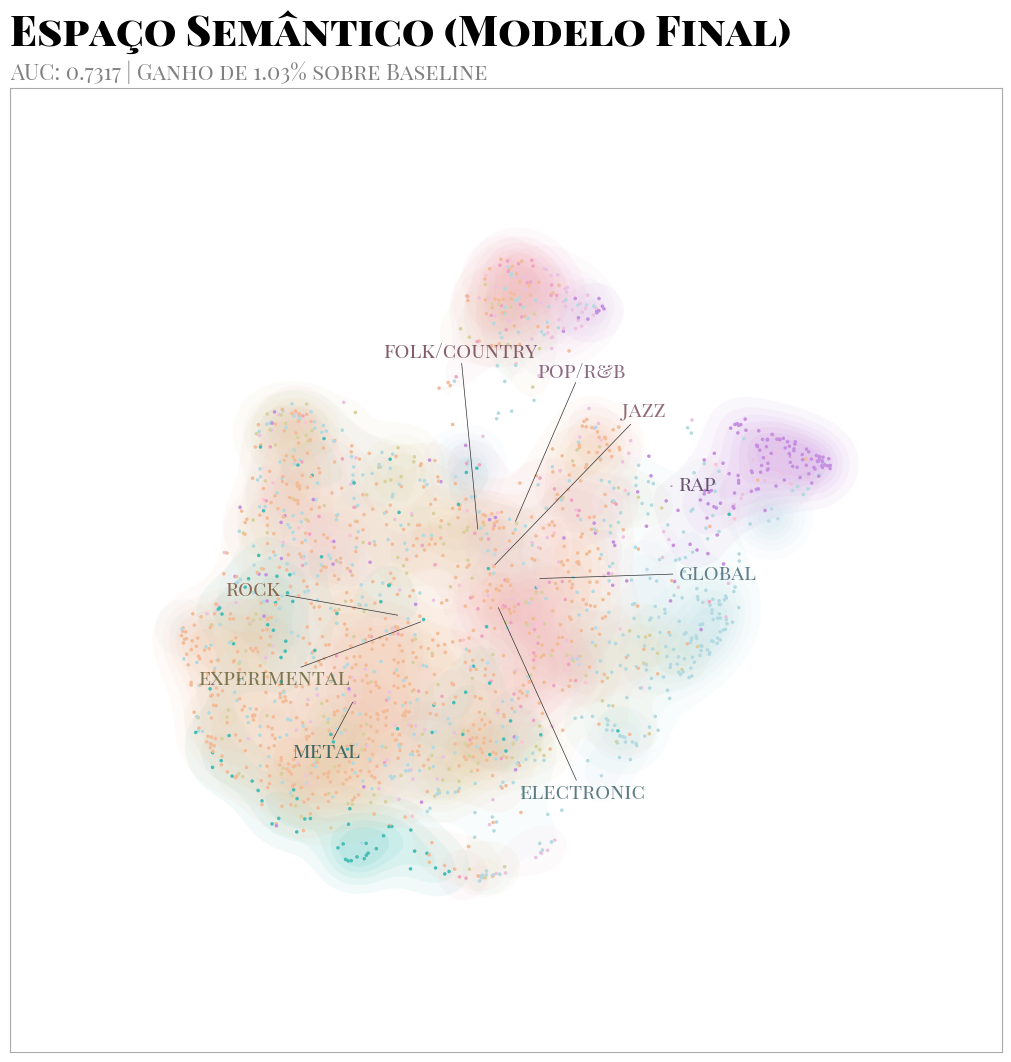

In [ ]:
# 3. Gerar UMAP e Plot
ump = umap.UMAP(n_neighbors=15, min_dist=0.1, metric='cosine', random_state=42)
embedding_2d = ump.fit_transform(embeddings)

fig, ax = datamapplot.create_plot(
    embedding_2d,
    sample_genre,
    title="Espaço Semântico (Modelo Final)",
    sub_title=f"AUC: 0.7317 | Ganho de 1.03% sobre Baseline",
    font_family="Playfair Display SC",
    label_linespacing=1.25,
    label_font_size=15,
    title_keywords={"fontsize":30, "fontfamily":"Playfair Display SC Black"},
    label_margin_factor=1.0,
    darkmode=False
)
plt.show()

###Explainable AI

In [ ]:
!pip install lime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 9.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=316fdcd55b8c9610e6481568cffe28df3e19c4410b20dffcb212050374f8e4c0
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


In [ ]:
import os
import keras
import keras_nlp
import tensorflow as tf
import numpy as np
from lime.lime_text import LimeTextExplainer

print("--- RECONSTRUINDO MODELO E RODANDO LIME (DEFINITIVO) ---")

# --- 1. CONFIGURAÇÕES E CAMADAS ---
PRESET = "distil_bert_base_en_uncased"
PATH_DRIVE = '/content/drive/MyDrive/MESTRADO/Disciplinas/Deep Learning/Paper - analysis/'

# Recriando o genre_lookup (Caso não esteja na memória)
# Lista padrão de gêneros (se tiver mais, adicione aqui ou use df['genre'].unique())
unique_genres = ['electronic', 'metal', 'rock', 'rap', 'experimental', 'pop/r&b', 'folk/country', 'jazz', 'global']
genre_lookup = keras.layers.StringLookup(vocabulary=unique_genres, output_mode="one_hot")

# --- 2. RECONSTRUÇÃO DA ARQUITETURA ---
# Inputs
text_input = keras.Input(shape=(), dtype="string", name="text_input")
genre_input = keras.Input(shape=(1,), dtype="string", name="genre_input")

# Backbone e Preprocessador
preprocessor = keras_nlp.models.DistilBertPreprocessor.from_preset(PRESET, sequence_length=256)
backbone = keras_nlp.models.DistilBertBackbone.from_preset(PRESET)

# Fluxo de Texto
x_text = preprocessor(text_input)
x_text = backbone(x_text)[:, 0, :]

# Fluxo de Gênero
x_genre = genre_lookup(genre_input)
x_genre = keras.layers.Dense(32, activation="relu")(x_genre)

# Fusão
combined = keras.layers.Concatenate()([x_text, x_genre])
x = keras.layers.Dense(64, activation="relu")(combined)
x = keras.layers.Dropout(0.3)(x)
outputs = keras.layers.Dense(1, activation="sigmoid")(x)

# Criar o Modelo
model_final = keras.Model(inputs=[text_input, genre_input], outputs=outputs)

# --- 3. CARREGAR OS PESOS TREINADOS (CRUCIAL!) ---
print("Carregando pesos salvos...")
try:
    model_final.load_weights(f'{PATH_DRIVE}/melhor_modelo_final.keras')
    print("Pesos carregados com sucesso!")
except Exception as e:
    print(f"Erro ao carregar pesos: {e}")
    print("O modelo rodará com pesos aleatórios (resultados não farão sentido).")

# --- 4. CONFIGURAÇÃO DO LIME ---

# Escolha do caso
idx_para_explicar = 15 # Pode mudar esse número
texto_real = test_texts[idx_para_explicar]
genero_real = test_genres[idx_para_explicar]

print(f"\nReview ID: {idx_para_explicar}")
print(f"Gênero: {genero_real}")
print(f"Texto (início): {texto_real[:100]}...")

# --- 5. FUNÇÃO WRAPPER (A "BLINDAGEM" COM TF.DATA) ---
def preditor_hibrido_final(lista_de_textos):
    n_samples = len(lista_de_textos)

    # Garantimos que é uma lista de strings Python
    lista_limpa = [str(x) for x in lista_de_textos]

    # Criamos tensores constantes
    textos = tf.constant(lista_limpa, dtype=tf.string)

    # Gênero: Criamos uma lista de listas para ter shape (N, 1)
    # Isso evita o erro de shape desconhecido
    lista_generos = [[str(genero_real)] for _ in range(n_samples)]
    generos = tf.constant(lista_generos, dtype=tf.string)

    # Criamos o Dataset (A Solução Mágica)
    # O from_tensor_slices organiza tudo internamente
    dataset = tf.data.Dataset.from_tensor_slices(
        {
            "text_input": textos,
            "genre_input": generos
        }
    )

    # Batches: Agrupa tudo de volta para passar no modelo de uma vez
    dataset = dataset.batch(n_samples)

    # Previsão
    probs = model_final.predict(dataset, verbose=0)

    # Retorna [Prob_Negativo, Prob_Positivo]
    return np.hstack([1 - probs, probs])

# Teste Rápido
print("\nTestando wrapper...")
teste = preditor_hibrido_final([texto_real])
print(f"Wrapper OK! Probabilidade: {teste}")

# --- 6. EXECUTAR LIME ---
explainer = LimeTextExplainer(class_names=["Negativo", "Positivo"])

print("\nCalculando importâncias (LIME)...")
exp = explainer.explain_instance(
    texto_real,
    preditor_hibrido_final,
    num_features=10,
    num_samples=100 # Se demorar, baixe para 50
)

# Visualizar
exp.show_in_notebook(text=True)

# Salvar
caminho_salvar = f'{PATH_DRIVE}/explicacao_lime_final_id{idx_para_explicar}.html'
exp.save_to_file(caminho_salvar)
print(f"\nSalvo em: {caminho_salvar}")

--- RECONSTRUINDO MODELO E RODANDO LIME (DEFINITIVO) ---
Carregando pesos salvos...
Pesos carregados com sucesso!

Review ID: 15
Gênero: electronic
Texto (início): Can you judge a band by its name? As fair-minded listeners, we try to resist the temptation, but we'...

Testando wrapper...
Wrapper OK! Probabilidade: [[0.8757058  0.12429422]]

Calculando importâncias (LIME)...



Salvo em: /content/drive/MyDrive/MESTRADO/Disciplinas/Deep Learning/Paper - analysis//explicacao_lime_final_id15.html


In [ ]:
!pip install shap

In [ ]:
import shap
import numpy as np
import tensorflow as tf
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt

print("--- INICIANDO CÁLCULO SHAP (ISSO VAI DEMORAR!) ---")
print("Calculando valores para um subconjunto para gerar os gráficos global e local.")

# --- CONFIGURAÇÃO ---
# Quantos exemplos usar para o gráfico global?
# 30-50 é um bom número para ter um gráfico de barras razoável sem demorar horas.
N_SAMPLES_SHAP = 50
subset_indices = range(N_SAMPLES_SHAP)

# Listas para armazenar os resultados de cada iteração
all_shap_values = []
processed_texts = []

# Definir o "Masker" de texto (o tokenizador padrão do SHAP)
masker = shap.maskers.Text(r"\W+")

print(f"\nProcessando {N_SAMPLES_SHAP} exemplos. Aguarde...")

# --- LOOP PRINCIPAL DO SHAP ---
# Iteramos por cada exemplo para garantir que o gênero correto seja usado
for i in tqdm(subset_indices, desc="Calculando SHAP"):
    # 1. Pegar os dados reais do exemplo atual
    texto_atual = test_texts[i]
    genero_atual = test_genres[i]

    # 2. Definir o Wrapper BLINDADO (Fixo para o gênero atual)
    # Essa função é recriada a cada loop para "travar" o gênero correto
    def wrapper_hibrido_atual(lista_de_textos):
        n = len(lista_de_textos)
        # Limpeza e conversão para Tensor (igual fizemos no LIME)
        lista_limpa = [str(x) for x in lista_de_textos]
        text_tensor = tf.constant(lista_limpa)

        # Gênero fixo do exemplo 'i' repetido N vezes
        lista_generos = [[str(genero_atual)] for _ in range(n)]
        genre_tensor = tf.constant(lista_generos)

        # Previsão (shape N, 1)
        probs = model_final.predict(
            {"text_input": text_tensor, "genre_input": genre_tensor},
            batch_size=n,
            verbose=0
        )
        # O SHAP para texto prefere o output direto (N, 1) ou achatado (N,)
        return probs.flatten()

    # 3. Criar o Explainer para este exemplo
    explainer = shap.Explainer(wrapper_hibrido_atual, masker, silent=True)

    # 4. Calcular SHAP Value (passamos o texto como lista)
    # max_evals controla a precisão vs tempo. 500 é um bom equilíbrio.
    shap_val = explainer([texto_atual], max_evals=500)

    # Armazenar resultado
    all_shap_values.append(shap_val)
    processed_texts.append(texto_atual)

print("\nCálculo concluído! Agregando resultados...")

--- INICIANDO CÁLCULO SHAP (ISSO VAI DEMORAR!) ---
Calculando valores para um subconjunto para gerar os gráficos global e local.

Processando 50 exemplos. Aguarde...


Calculando SHAP:   0%|          | 0/50 [00:00<?, ?it/s]


Cálculo concluído! Agregando resultados...


ValueError: all the input array dimensions except for the concatenation axis must match exactly, but along dimension 1, the array at index 0 has size 629 and the array at index 1 has size 912

--- GERANDO GRÁFICOS SHAP (CORREÇÃO FINAL) ---
Dados extraídos com sucesso! Total de tokens processados: 35994


/tmp/ipython-input-2093863746.py:66: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


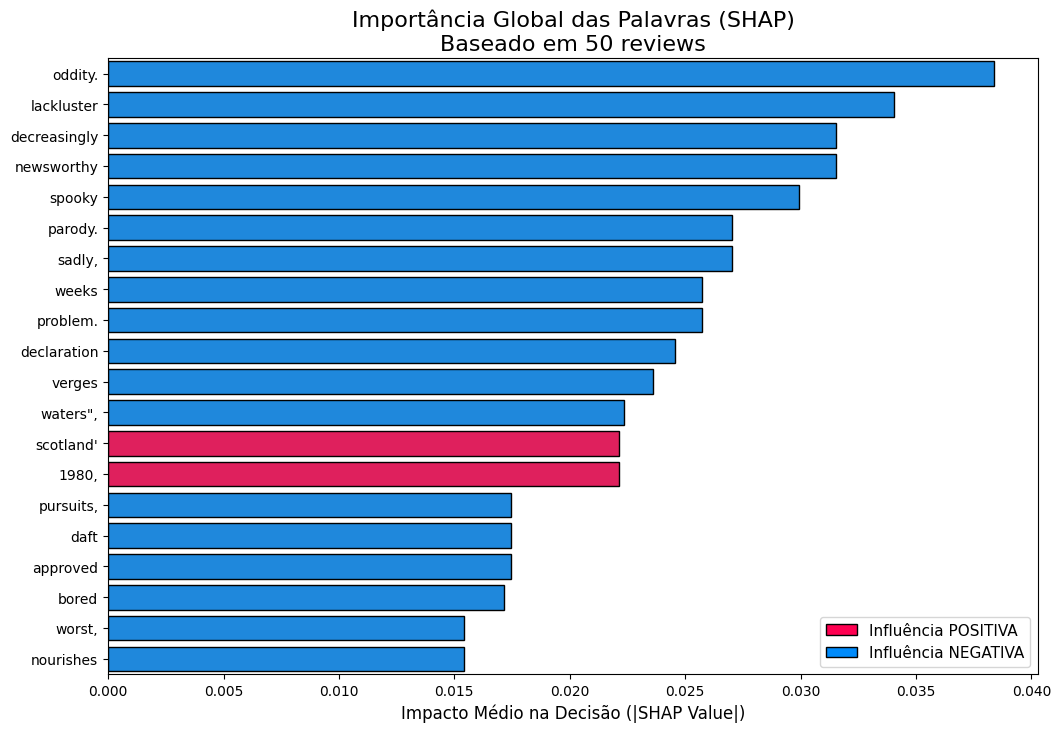

Gráfico Global salvo em: /content/drive/MyDrive/MESTRADO/Disciplinas/Deep Learning/Paper - analysis//shap_global_final.png
--- Gerando Force Plot Local com Rótulos (Estilo Tabular) ---


<Figure size 2000x300 with 0 Axes>

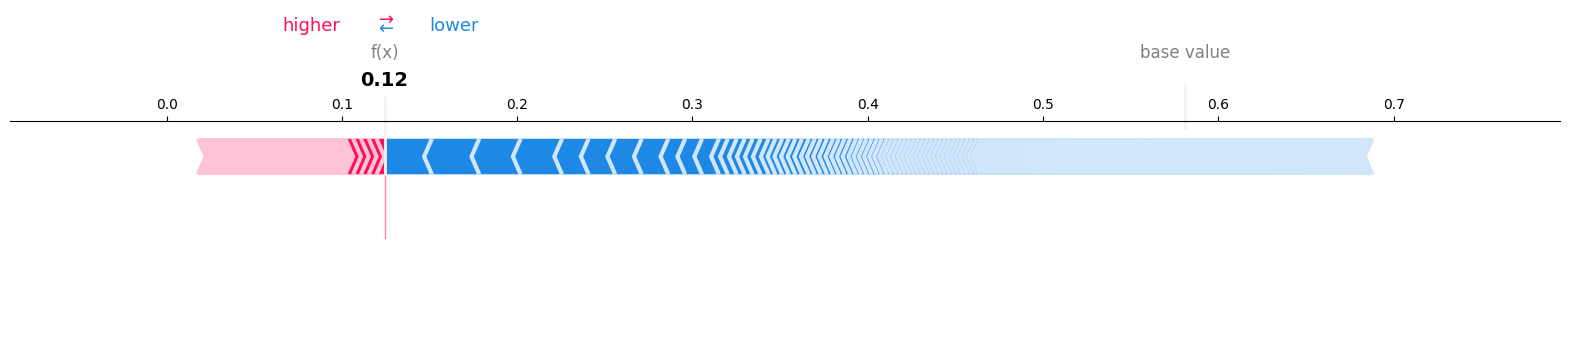

Gráfico Local (com labels) salvo em: /content/drive/MyDrive/MESTRADO/Disciplinas/Deep Learning/Paper - analysis//shap_force_plot_with_labels.png


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np

print("--- GERANDO GRÁFICOS SHAP (CORREÇÃO FINAL) ---")

# Lista para armazenar dados limpos
word_data = []

# ITERAÇÃO CORRIGIDA
for i, sv in enumerate(all_shap_values):
    # CORREÇÃO CRÍTICA AQUI:
    # sv.values é (1, N). Precisamos de sv.values[0] para ter o array (N,)
    # sv.data é (1, N) ou (N,). Forçamos pegar o conteúdo interno.

    # Verifica dimensões para garantir
    if len(sv.values.shape) == 2:
        token_scores = sv.values[0]
        token_words = sv.data[0]
    else:
        token_scores = sv.values
        token_words = sv.data

    # Agora o zip vai pegar (palavra, numero) corretamente
    for word, value in zip(token_words, token_scores):
        word_clean = str(word).strip().lower()

        # Ignorar tokens inúteis do BERT
        if word_clean in ["", "[pad]", "[cls]", "[sep]", "[unk]"]:
            continue

        word_data.append({
            "word": word_clean,
            "shap_value": float(value),      # Garante que é float python puro
            "abs_value": float(abs(value))   # Garante que é float python puro
        })

# 1. Criar DataFrame
df_shap = pd.DataFrame(word_data)

# Verificação de segurança (Se o DF estiver vazio, avisa)
if df_shap.empty:
    print("ERRO: Nenhum dado foi extraído. Verifique se all_shap_values está preenchido.")
else:
    print(f"Dados extraídos com sucesso! Total de tokens processados: {len(df_shap)}")

    # 2. Agrupar e Calcular Médias
    df_grouped = df_shap.groupby("word").agg({
        "shap_value": "mean",
        "abs_value": "mean",
        "word": "count"
    }).rename(columns={"word": "count"}).reset_index()

    # Filtro opcional: Só palavras que apareceram mais de 1 vez (remove ruído)
    # df_grouped = df_grouped[df_grouped["count"] > 1]

    # 3. Ordenar (Agora vai funcionar pois são floats puros)
    top_words = df_grouped.sort_values("abs_value", ascending=False).head(20)

    # 4. Configurar Cores (Vermelho=Positivo, Azul=Negativo)
    colors = ['#ff0051' if x > 0 else '#008bfb' for x in top_words['shap_value']]

    # 5. PLOTAR GRÁFICO GLOBAL
    plt.figure(figsize=(12, 8))
    sns.barplot(
        data=top_words,
        x="abs_value",
        y="word",
        palette=colors,
        edgecolor="black"
    )

    plt.title(f"Importância Global das Palavras (SHAP)\nBaseado em {len(all_shap_values)} reviews", fontsize=16)
    plt.xlabel("Impacto Médio na Decisão (|SHAP Value|)", fontsize=12)
    plt.ylabel(None)

    # Legenda Personalizada
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='#ff0051', edgecolor='black', label='Influência POSITIVA'),
        Patch(facecolor='#008bfb', edgecolor='black', label='Influência NEGATIVA')
    ]
    plt.legend(handles=legend_elements, loc='lower right', fontsize=11)

    # Salvar
    path_global = f'{PATH_DRIVE}/shap_global_final.png'
    plt.savefig(path_global, bbox_inches='tight', dpi=300)
    plt.show()
    print(f"Gráfico Global salvo em: {path_global}")


# ==============================================================================
# GRÁFICO LOCAL (Mantido igual pois funcionava)
# ==============================================================================

print("--- Gerando Force Plot Local com Rótulos (Estilo Tabular) ---")

# 1. Configuração do Review 15
idx_local = 15
if idx_local >= len(all_shap_values):
    idx_local = 0

# Pegamos o objeto SHAP individual
shap_val_local = all_shap_values[idx_local]

# 2. TRUQUE PARA APARECER OS NOMES:
# Extraímos explicitamente os valores e os nomes (palavras)
# shap_val_local[0].values -> Os números
# shap_val_local[0].data -> As palavras
# Ao passar 'feature_names', forçamos o SHAP a tratar como Tabela e mostrar os labels.

plt.figure(figsize=(20, 3)) # Largura maior para caber as palavras
shap.plots.force(
    base_value=shap_val_local[0].base_values,
    shap_values=shap_val_local[0].values,
    feature_names=shap_val_local[0].data, # <--- O SEGREDO ESTÁ AQUI
    matplotlib=True,
    show=False
)

# Salvar
path_force_labels = f'{PATH_DRIVE}/shap_force_plot_with_labels.png'
plt.savefig(path_force_labels, bbox_inches='tight', dpi=300)
plt.show()
print(f"Gráfico Local (com labels) salvo em: {path_force_labels}")

In [ ]:
# Versão HTML (Interativa - Igualzinho à Referência)
print("--- Gerando Versão HTML (Interativa) ---")

shap.initjs() # Inicializa JS no Colab

plot_html = shap.force_plot(
    base_val,
    shap_vals,
    feature_names=words
)

# Salvar como arquivo HTML
path_html = f'{PATH_DRIVE}/shap_force_plot_tabular.html'
shap.save_html(path_html, plot_html)
print(f"Arquivo HTML salvo em: {path_html}")
print("DICA: Abra esse arquivo no navegador e tire um print para ficar perfeito no artigo!")

# Mostrar no notebook
plot_html

--- Gerando Versão HTML (Interativa) ---


Arquivo HTML salvo em: /content/drive/MyDrive/MESTRADO/Disciplinas/Deep Learning/Paper - analysis//shap_force_plot_tabular.html
DICA: Abra esse arquivo no navegador e tire um print para ficar perfeito no artigo!
